In [2]:
import pandas as pd

import numpy as np

In [3]:
data = pd.read_csv('Cars_cluster.csv')

df = data.copy()

print()
print(f"Shape: {df.shape}")
print()

df.head()


Shape: (100, 16)



,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,part
0,Acura,Integra,16.919,16.360,0,21.50,1.8,140,101.2,67.3,172.4,2.639,13.2,28,2.828,1
1,Acura,TL,39.384,19.875,0,28.40,3.2,225,108.1,70.3,192.9,3.517,17.2,25,3.673,2
2,Acura,CL,14.114,18.225,0,25.00,3.2,225,106.9,70.6,192.0,3.470,17.2,26,2.647,3
3,Acura,RL,8.588,29.725,0,42.00,3.5,210,114.6,71.4,196.6,3.850,18.0,22,2.150,1
4,Audi,A4,20.397,22.255,0,23.99,1.8,150,102.6,68.2,178.0,2.998,16.4,27,3.015,2


In [4]:
x = df[['engine_s', 'horsepow', 'wheelbas', 'width', 'length', 'curb_wgt', 'fuel_cap', 'mpg', 'lnsales']]

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_normalize = scaler.fit_transform(x)

In [6]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

In [7]:
z = linkage(x, method = 'complete', metric = 'euclidean')

In [8]:
cluster_maxclust = fcluster(z, t = 5, criterion = 'maxclust')

In [9]:
cluster_distance = fcluster(z, 3, criterion = 'distance')

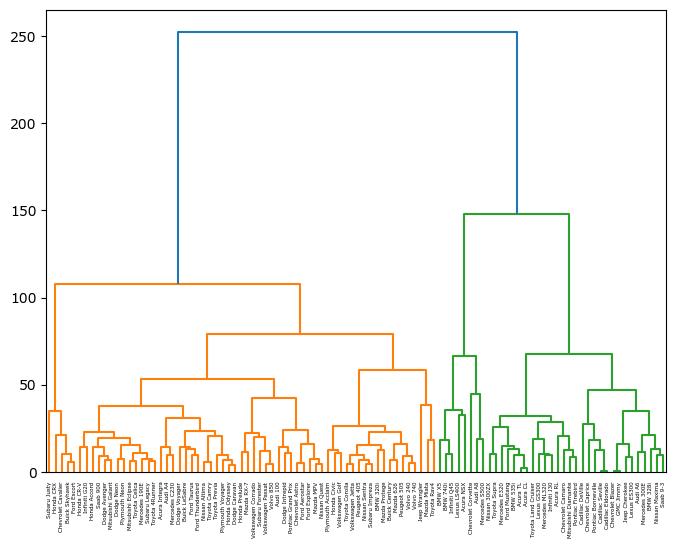

In [10]:
import matplotlib.pyplot as plt

fig = plt.figure( figsize = (8, 6) )

def llf(id):
    return f"{df['manufact'][id]} {df['model'][id]}"
    
dendo = dendrogram(z, leaf_label_func = llf, leaf_rotation = 90, leaf_font_size = 4)

In [11]:
df['Cluster'] = cluster_maxclust

print(set(cluster_maxclust))

{np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5)}


In [12]:
df.head()

,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,part,Cluster
0,Acura,Integra,16.919,16.360,0,21.50,1.8,140,101.2,67.3,172.4,2.639,13.2,28,2.828,1,2
1,Acura,TL,39.384,19.875,0,28.40,3.2,225,108.1,70.3,192.9,3.517,17.2,25,3.673,2,5
2,Acura,CL,14.114,18.225,0,25.00,3.2,225,106.9,70.6,192.0,3.470,17.2,26,2.647,3,5
3,Acura,RL,8.588,29.725,0,42.00,3.5,210,114.6,71.4,196.6,3.850,18.0,22,2.150,1,5
4,Audi,A4,20.397,22.255,0,23.99,1.8,150,102.6,68.2,178.0,2.998,16.4,27,3.015,2,2


In [13]:
n_clusters = max(cluster_maxclust)

colors = plt.cm.Spectral(np.linspace(0, 1, n_clusters))

cluster_labels = list(range(1, n_clusters + 1))

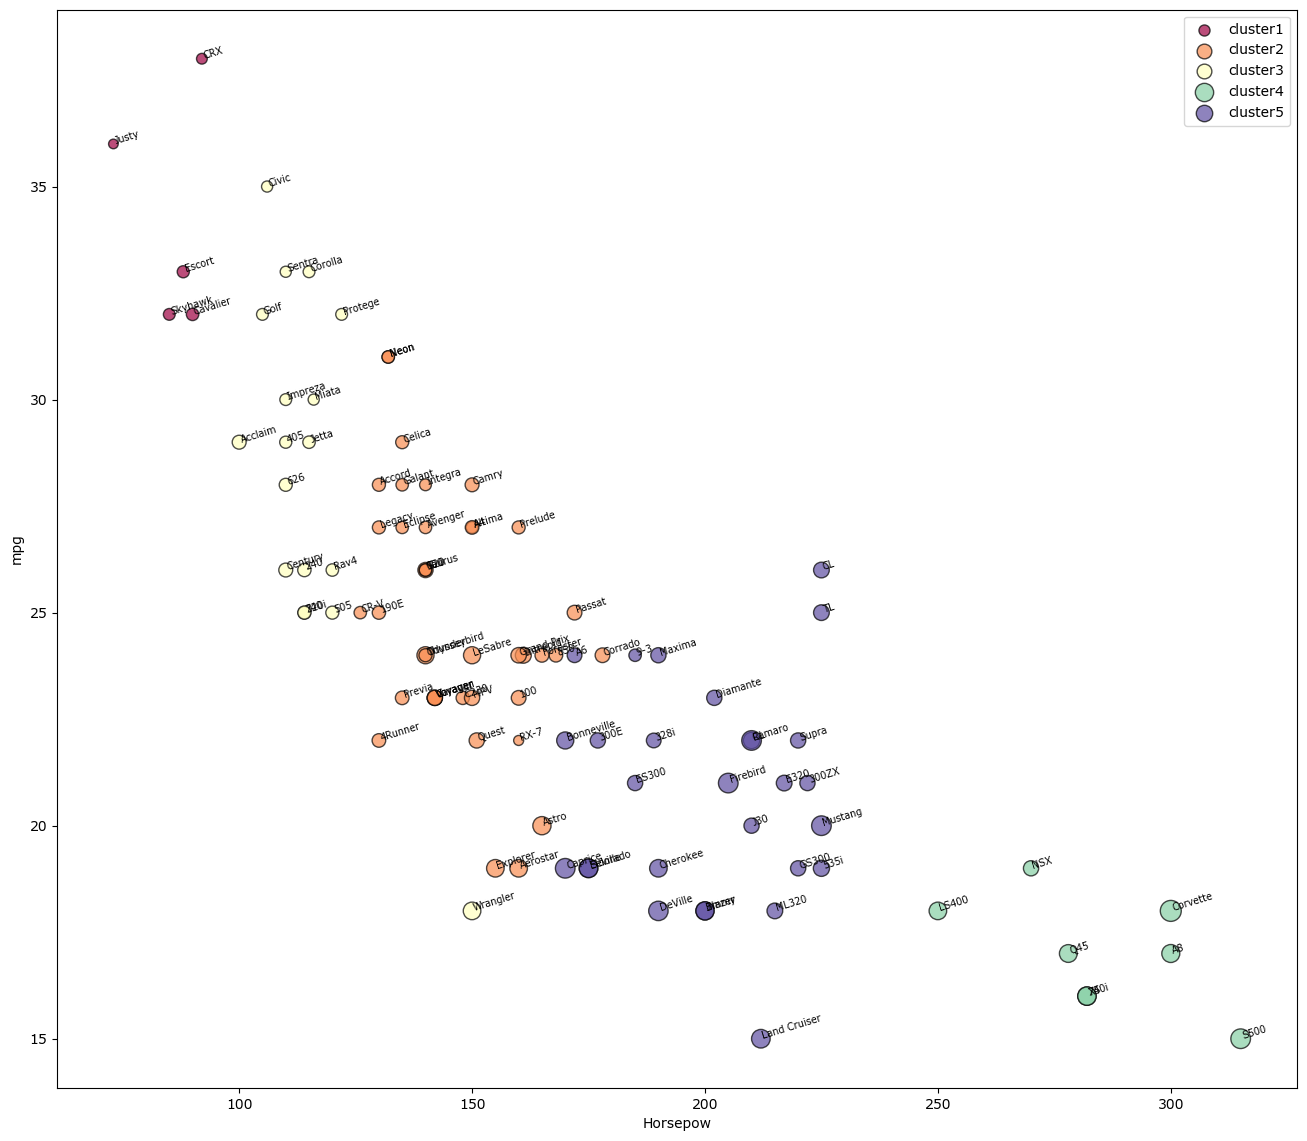

In [14]:
plt.figure( figsize = (16, 14) )

for color, label in zip(colors, cluster_labels) :
    
    msk = ( df[ df['Cluster'] == label ] )
    
    plt.scatter( msk['horsepow'], msk['mpg'], s = msk['engine_s'] * 40, color = color, label = 'cluster' + str(label), alpha = 0.7, edgecolor = 'k')
    
    for i in msk.index :
        plt.text(msk['horsepow'][i] , msk['mpg'][i] , str(msk['model'][i]), rotation = 17, fontsize = 7)

plt.xlabel('Horsepow')
plt.ylabel('mpg')

plt.legend()

In [15]:
df.groupby(['Cluster', 'type'])['Cluster'].count()

Cluster  type
1        0        5
2        0       40
3        0       18
4        0        8
5        0       29
Name: Cluster, dtype: int64

In [16]:
cars = df.groupby(['Cluster', 'type'])[['horsepow', 'engine_s', 'mpg', 'price']].mean()

cars

,,horsepow,engine_s,mpg,price
Cluster,type,,,,
1,0,85.60000,1.680000,34.200000,11.400000
2,0,146.72500,2.595000,24.875000,23.099750
3,0,114.50000,2.105556,28.388889,18.716667
4,0,284.62500,4.350000,17.000000,64.375000
5,0,200.37931,3.658621,20.793103,34.058621


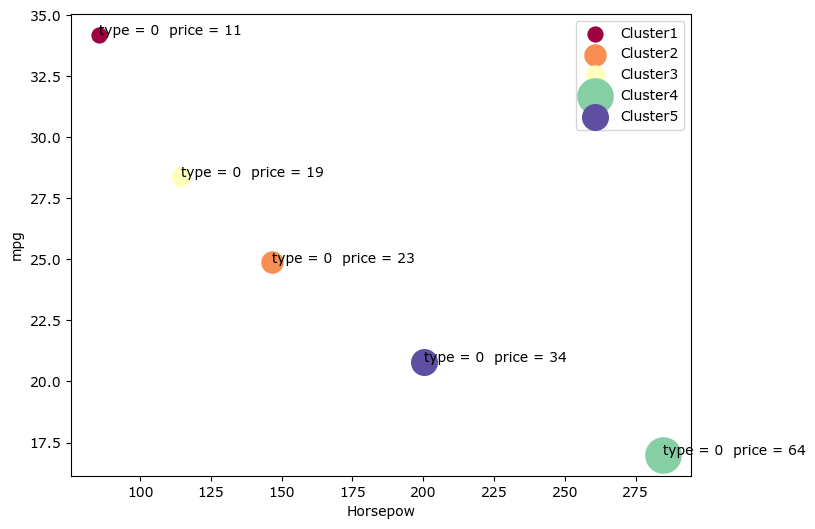

In [17]:
plt.figure( figsize = (8, 6) )

for color, label in zip(colors, cluster_labels):
    
    msk = cars.loc[ (label, ), ]
    
    for i in msk.index :
        plt.text(msk.loc[i, 'horsepow'], msk.loc[i, 'mpg'], f"type = {str(i)}  price = {msk.loc[i, 'price']:1.0f}")
        
    plt.scatter( msk['horsepow'], msk['mpg'], s = msk['price'] * 10, color = color, label = 'Cluster' + str(int(label)) )

plt.xlabel('Horsepow')
plt.ylabel('mpg')

plt.legend()